In [16]:
#part a)
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

Slope: -1.0124157441938133, Intercept: 11.973485408588264


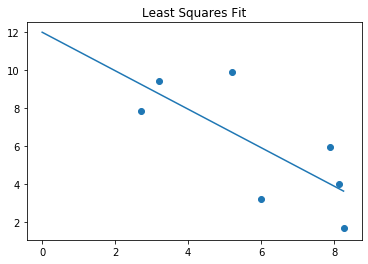

In [89]:
#Parameters
elementLimit = 10
elementValueLimit = 10

# Data points
X = np.random.rand(np.ceil(rng.random()*elementLimit).astype(int))*elementValueLimit
X.sort()
Y = np.random.rand(len(X))*elementValueLimit

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")
x = np.linspace(0,np.max(X),np.max(X)+1)

plt.plot(x, m*x + c)
plt.scatter(X,Y)
plt.title("Least Squares Fit")
plt.show()

Polynomial Coefficients:  [  0.27437436  -4.68993713  23.85549366 -27.78813455]


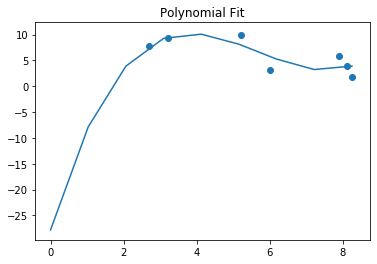

In [90]:
#Polynomial Fitting
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)
print("Polynomial Coefficients: ", coefficients)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

plt.plot(x, y_pred)
plt.scatter(X,Y)
plt.title("Polynomial Fit")
plt.show()

In [91]:
#Polyfit
y_calcpoly = polynomial(X)
print('The MSE and R^2 values for the polyfit method:\n')

# Mean Squared Error (MSE)
polymse = np.mean((Y - y_calcpoly)**2)
print(f'Mean Squared Error: {polymse:.4f}')

# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_calcpoly)**2)
polyr_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {polyr_squared:.4f}')

The MSE and R^2 values for the polyfit method:

Mean Squared Error: 3.2011
R-squared: 0.6293


In [92]:
#Least Squares
y_calclin = m * X + c
print('The MSE and R^2 values for the least squares method:\n')

# Mean Squared Error (MSE)
lstsqmse = np.mean((Y - y_calclin)**2)
print(f'Mean Squared Error: {lstsqmse:.4f}')

# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_calclin)**2)
lstsqr_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {lstsqr_squared:.4f}')

The MSE and R^2 values for the least squares method:

Mean Squared Error: 3.9007
R-squared: 0.5482


In [93]:
if (lstsqmse < polymse) and (abs(lstsqr_squared-1)<abs(polyr_squared-1)):
    print("The least squares method is the better fit for this data set")
else:
        print("The polyfit method is the better fit for this data set")

The polyfit method is the better fit for this data set


Increasing polynomial degree:


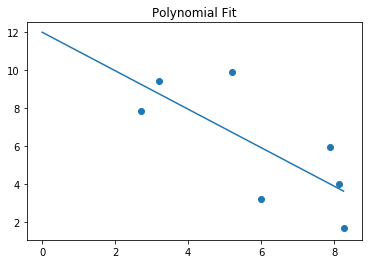

Degree 1: MSE = 3.9007, R^2 = 0.5482


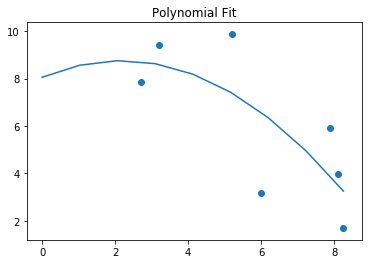

Degree 2: MSE = 3.6982, R^2 = 0.5717


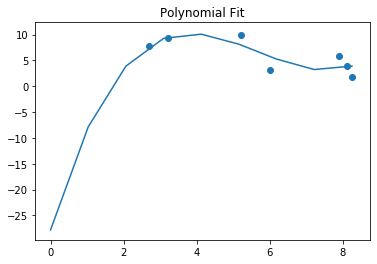

Degree 3: MSE = 3.2011, R^2 = 0.6293


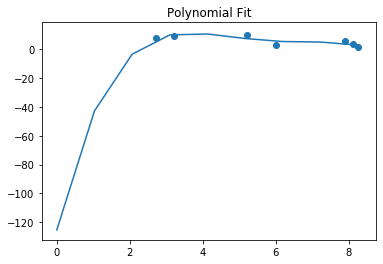

Degree 4: MSE = 2.6358, R^2 = 0.6947


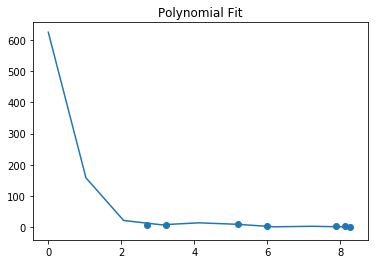

Degree 5: MSE = 0.0008, R^2 = 0.9999


In [94]:
#part b)
polymse = 10
polyr_squared = 10
degree = 1

print("Increasing polynomial degree:")
while (((polymse+polyr_squared)-1)>1e-3):
    coefficients = np.polyfit(X, Y, degree)
    polynomial = np.poly1d(coefficients)

    y_pred = polynomial(X)

    # MSE
    polymse = np.mean((Y - y_pred)**2)

    # R-squared
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - y_pred)**2)
    polyr_squared = 1 - (ss_res / ss_total)
    
    # Plot
    y_pred = polynomial(x)
    plt.plot(x, y_pred)
    plt.scatter(X,Y)
    plt.title("Polynomial Fit")
    plt.show()

    print(f"Degree {degree}: MSE = {polymse:.4f}, R^2 = {polyr_squared:.4f}")
    degree += 1

Decreasing polynomial degree:


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


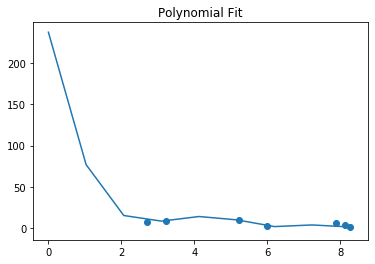

Degree 10: MSE = 0.0000, R^2 = 1.0000


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


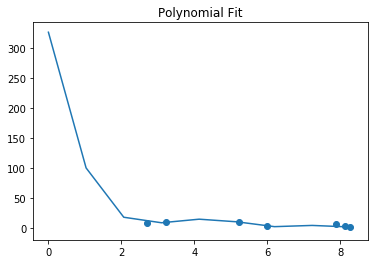

Degree 9: MSE = 0.0000, R^2 = 1.0000


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


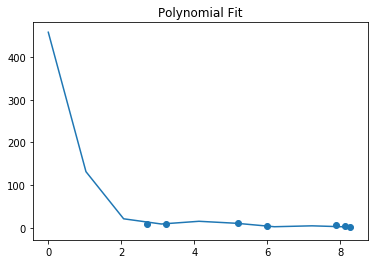

Degree 8: MSE = 0.0000, R^2 = 1.0000


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


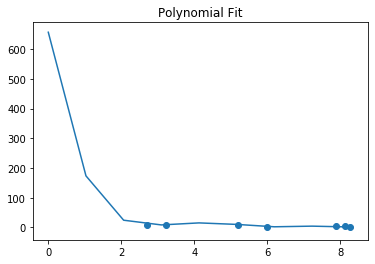

Degree 7: MSE = 0.0000, R^2 = 1.0000


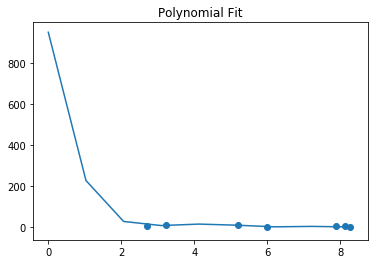

Degree 6: MSE = 0.0000, R^2 = 1.0000


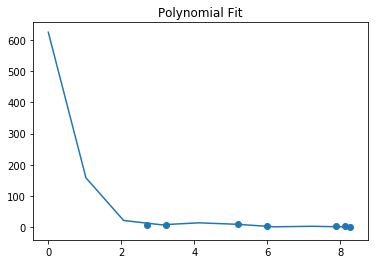

Degree 5: MSE = 0.0008, R^2 = 0.9999


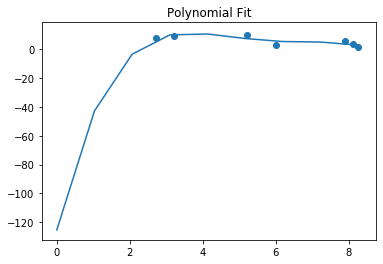

Degree 4: MSE = 2.6358, R^2 = 0.6947


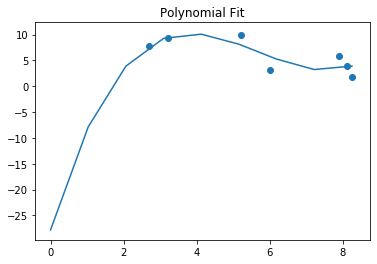

Degree 3: MSE = 3.2011, R^2 = 0.6293


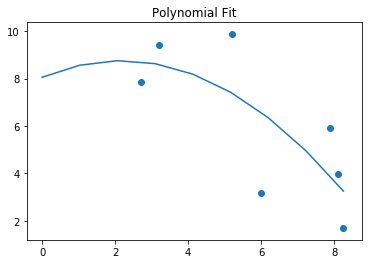

Degree 2: MSE = 3.6982, R^2 = 0.5717


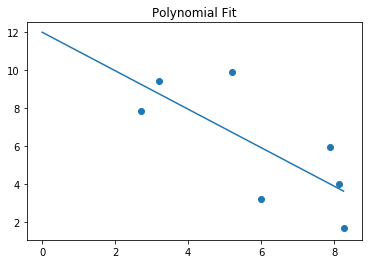

Degree 1: MSE = 3.9007, R^2 = 0.5482


In [97]:
print("Decreasing polynomial degree:")

for degree in range(10, 0, -1):

    coefficients = np.polyfit(X, Y, degree)
    polynomial = np.poly1d(coefficients)

    y_pred = polynomial(X)

    polymse = np.mean((Y - y_pred)**2)

    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - y_pred)**2)
    polyr_squared = 1 - (ss_res / ss_total)
    
    # Plot
    y_pred = polynomial(x)
    plt.plot(x, y_pred)
    plt.scatter(X,Y)
    plt.title("Polynomial Fit")
    plt.show()

    print(f"Degree {degree}: MSE = {polymse:.4f}, R^2 = {polyr_squared:.4f}")

In [99]:
#We can see it begins to overfit at degree 4 (and maybe 3) and begins to underfit at degree 1.

In [100]:
#part c)
def create_vandermonde_matrix(x, degree):
    n = len(x)
    V = np.zeros((n, degree+1))
    for i in range(degree+1):
        V[:,i] = x**i
        
    return V

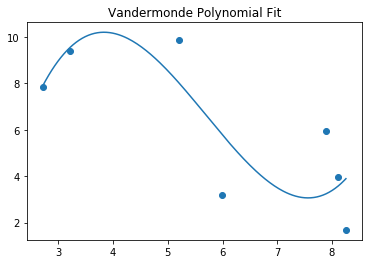

In [101]:
degree = 3
V = create_vandermonde_matrix(X, degree)
coefficients = np.linalg.lstsq(V, Y, rcond=None)[0]

y_pred = V @ coefficients

x_line = np.linspace(min(X), max(X), 200)
V_plot = create_vandermonde_matrix(x_line, degree)
y_line = V_plot @ coefficients

plt.scatter(X,Y)
plt.plot(x_line,y_line)
plt.title("Vandermonde Polynomial Fit")
plt.show()

In [102]:
mse = np.mean((Y - y_pred)**2)
print("MSE:", mse)

ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_pred)**2)
r_squared = 1 - (ss_res/ss_total)
print("R^2:", r_squared)

MSE: 3.201081955115737
R^2: 0.6292737768252348


In [103]:
#vandemonde method is lowk goated icl